# Microsoft Yaz Stajı — AMZN Kapanış Fiyatı Tahmini (LSTM vs GRU)

Bu notebook, `src/` altındaki modülleri sırayla çağırarak tüm pipeline'ı baştan sona çalıştırır:
veri yükleme → keşifsel analiz → ön işleme → baseline modeller → LSTM → GRU → değerlendirme.

Not: Grafik/tahmin çıktıları `results/` klasörüne de kaydedilir; bu notebook üretimi tekrarlar
ve aynı sonuçları burada da gösterir (seed sabit, 42).

In [1]:
import sys
from pathlib import Path

# notebooks/ icinden veya proje kokunden calistirilabilsin diye src/ yolunu ekle.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import io
import pickle
import json

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

%matplotlib inline
import matplotlib.pyplot as plt

RESULTS_DIR = PROJECT_ROOT / "results"


def show_fig(fig, dpi=120):
    # src/ modulleri (explore.py vb.) matplotlib.use("Agg") cagirdigi icin bu satirdan
    # sonra %matplotlib inline'in interaktif backend'i gecersiz kalir; figuru PNG'ye
    # kodlayip display() ile gostermek backend'den bagimsiz calisir.
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)


print("Proje kok dizini:", PROJECT_ROOT)

Proje kok dizini: C:\Users\pc\Documents\GitHub\microsoft summer\stock_price_prediction_microsoft


## 1. Veri Yükleme

`data_loader.load_stock_data()`: AMZN günlük OHLCV verisini `data/AMZN.csv`'den okur
(yoksa yfinance ile indirir). Modele sadece `Close` sütunu girecek.

In [2]:
from data_loader import load_stock_data

df = load_stock_data()
df.tail()

[data_loader] 'AMZN.csv' diskten okundu (indirme atlandi).
[data_loader] Satir sayisi: 4170
[data_loader] Tarih araligi: 2010-01-04 -> 2026-08-03


,Close,High,Low,Open,Volume
Date,,,,,
2026-07-28,230.860001,233.110001,228.100006,232.850006,44521600
2026-07-29,226.649994,232.820007,226.160004,229.320007,44957500
2026-07-30,235.500000,239.820007,231.059998,233.350006,101839800
2026-07-31,271.579987,273.230011,262.010010,265.000000,128881300
2026-08-03,284.019989,287.160004,278.000000,278.290009,86041006


## 2. Keşifsel Analiz

`explore.explore()`: temel istatistikler, NaN kontrolü (varsa forward/backward fill),
iş günü takvimine göre eksik gün sayısı ve tüm zaman fiyat grafiği (`results/price_history.png`).

[explore] --- Temel istatistikler ---
             Close         High          Low         Open        Volume
count  4170.000000  4170.000000  4170.000000  4170.000000  4.170000e+03
mean     86.016713    87.022581    84.962730    86.033920  7.973950e+07
std      73.807138    74.683606    72.915505    73.834408  5.079585e+07
min       5.430500     5.564500     5.290000     5.296500  1.142050e+07
25%      15.714375    15.890000    15.564000    15.722750  4.908678e+07
50%      75.864750    77.077999    74.909000    76.275497  6.663500e+07
75%     152.856503   154.887497   150.746750   153.097256  9.489850e+07
max     284.019989   287.160004   278.000000   278.290009  8.484220e+08
[explore] Toplam NaN sayisi (fill oncesi): 0
[explore] NaN yok, fill uygulanmadi.
[explore] Is gunu takviminde eksik gun sayisi (tatiller dahil): 156
[explore] (Bu gunler borsa tatilleri olabilir; seri kronolojik ve monoton mu: True)
[explore] Fiyat grafigi kaydedildi: price_history.png


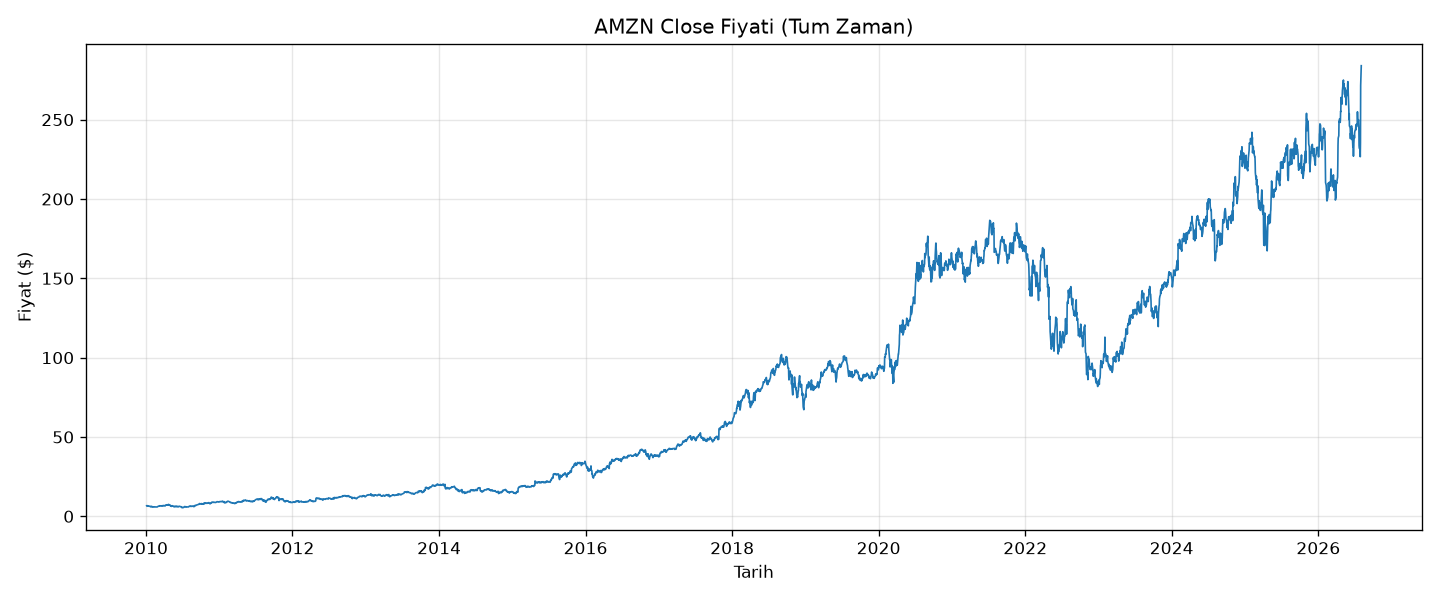

In [3]:
from explore import explore

df = explore(df)
display(Image(filename=str(RESULTS_DIR / "price_history.png")))

## 3. Ön İşleme

- `chronological_split`: ilk %80 train, son %20 test (shuffle yok — zaman serisi sırası korunur).
- `to_log_returns`: fiyat yerine günlük log-return'e geçiyoruz. **Neden:** `MinMaxScaler` fiyat
  SEVİYESİNE fit edilirse (train max ~$186), test döneminde fiyat bu aralığın dışına çıktığında
  (test'te $284'e kadar çıkıyor) model daha önce hiç görmediği bir ölçekte ekstrapolasyon yapmak
  zorunda kalıyor ve sistematik olarak düşük tahmin üretiyor. Return'ler dar ve durağan bir
  aralıkta kaldığı için bu sorunu ortadan kaldırıyor.
- `fit_scaler`: `MinMaxScaler(-1, 1)` SADECE train return'lerine fit edilir (leakage yok),
  `results/scaler.pkl` olarak kaydedilir.
- `create_sequences` / `make_tensors` (windowing.py): 20 günlük kayan pencerelerle `(X, y)` çiftleri.

In [4]:
from preprocessing import chronological_split, to_log_returns, fit_scaler, transform_series
from windowing import make_tensors, LOOKBACK

tr, te = chronological_split(df["Close"])

tr_returns = to_log_returns(tr)                       # train: "onceki gun" yok -> ilk gun return=0
te_returns = to_log_returns(te, prev_price=tr.values[-1])  # test: ilk gun train'in son fiyatina gore

scaler = fit_scaler(tr_returns)

Xtr, ytr = make_tensors(transform_series(scaler, tr_returns), name="train")
Xte, yte = make_tensors(transform_series(scaler, te_returns), name="test")
print(f"LOOKBACK = {LOOKBACK}")

[preprocessing] Toplam: 4170 | Train: 3336 | Test: 834
[preprocessing] Train tarih: 2010-01-04 -> 2023-04-04
[preprocessing] Test  tarih: 2023-04-05 -> 2026-08-03
[preprocessing] Scaler kaydedildi: scaler.pkl (fit araligi: -0.15 - 0.15)
[windowing] train X shape: (3316, 20, 1) | y shape: (3316, 1)
[windowing] test X shape: (814, 20, 1) | y shape: (814, 1)
LOOKBACK = 20


## 4. Baseline Modeller

`baselines.py`: **Naive** (dünkü fiyatı yarına kopyala) ve **Linear Regression** (20 günlük
düzleştirilmiş pencere) — ikisi de dolar cinsinden ham fiyatla çalışır, ölçekleme gerekmez.
Bu adımın kendi çıktısı `results/baseline_metrics.json`'a kaydedilir; Naive burada TÜM test
setinde (833 gün) hesaplanır — aşağıdaki "Değerlendirme" bölümünde LSTM/GRU ile aynı gün
kümesine (814 gün) kısıtlanarak adil biçimde yeniden karşılaştırılacak.

In [5]:
from baselines import compute_baselines

baseline_metrics = compute_baselines(tr.values, te.values, lookback=LOOKBACK)
baseline_metrics

[baselines] Naive             -> RMSE: $4.01 | MAE: $2.80
[baselines] LinearRegression  -> RMSE: $4.09 | MAE: $2.87
[baselines] Metrikler kaydedildi: baseline_metrics.json


{'naive': {'rmse': 4.011934249805545, 'mae': 2.796182263799073},
 'linear_regression': {'rmse': 4.086211209594947, 'mae': 2.8660638845956514}}

## 5. LSTM

`models.StockLSTM`: `nn.LSTM(input_size=1, hidden_size=32, num_layers=2, batch_first=True)`
+ `nn.Linear(32, 1)`. Her `forward` çağrısında `h0`/`c0` sıfırdan başlatılır, LSTM çıktısının
SON zaman adımı Linear katmana verilir. `train.train_model` (MSE + Adam, shuffle'lı
DataLoader) ile 100 epoch eğitiliyor; model artık fiyat değil, ölçeklenmiş log-return
tahmin ediyor.

[train] epoch   10/100 | loss: 0.019679


[train] epoch   20/100 | loss: 0.019675


[train] epoch   30/100 | loss: 0.019688


[train] epoch   40/100 | loss: 0.019720


[train] epoch   50/100 | loss: 0.019866


[train] epoch   60/100 | loss: 0.019707


[train] epoch   70/100 | loss: 0.019727


[train] epoch   80/100 | loss: 0.019743


[train] epoch   90/100 | loss: 0.019824


[train] epoch  100/100 | loss: 0.019708
[train] Egitim tamamlandi: 21.81s (100 epoch)


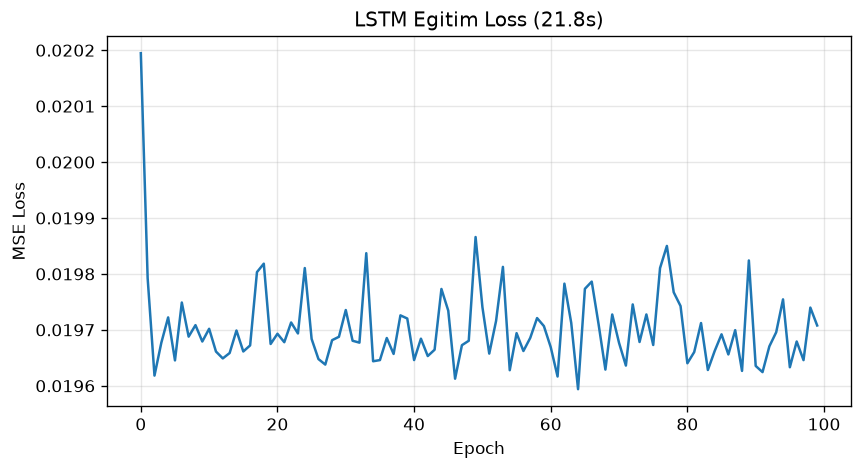

In [6]:
from models import StockLSTM
from train import train_model

torch.manual_seed(42)
lstm_model = StockLSTM()
lstm_model, lstm_losses, lstm_time = train_model(lstm_model, Xtr, ytr, epochs=100)

torch.save(lstm_model.state_dict(), RESULTS_DIR / "lstm_model.pt")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_losses, color="tab:blue")
ax.set_title(f"LSTM Egitim Loss ({lstm_time:.1f}s)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True, alpha=0.3)
show_fig(fig)

## 6. GRU

`models.StockGRU`: LSTM ile birebir aynı yapı (2 katman, hidden=32, `Linear(32,1)`); tek fark
`nn.GRU` kullanılması ve cell state olmaması (sadece `h0`). `train_model` fonksiyonu
değiştirilmeden, aynı şekilde 100 epoch eğitiliyor — adil karşılaştırma için seed yine 42'ye
resetleniyor (LSTM'in ağırlık başlatma/DataLoader shuffle sırasının GRU'yu etkilememesi için).

[train] epoch   10/100 | loss: 0.019691


[train] epoch   20/100 | loss: 0.019789


[train] epoch   30/100 | loss: 0.019676


[train] epoch   40/100 | loss: 0.019781


[train] epoch   50/100 | loss: 0.019765


[train] epoch   60/100 | loss: 0.019711


[train] epoch   70/100 | loss: 0.019921


[train] epoch   80/100 | loss: 0.019872


[train] epoch   90/100 | loss: 0.019813


[train] epoch  100/100 | loss: 0.019800
[train] Egitim tamamlandi: 54.52s (100 epoch)


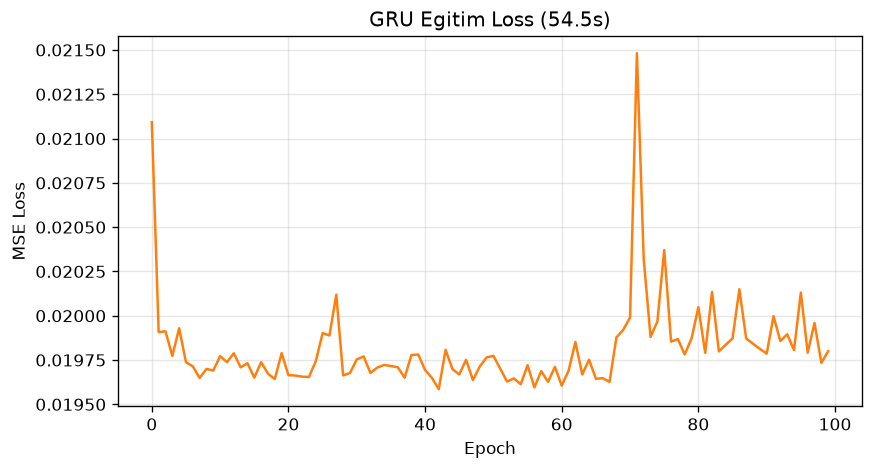

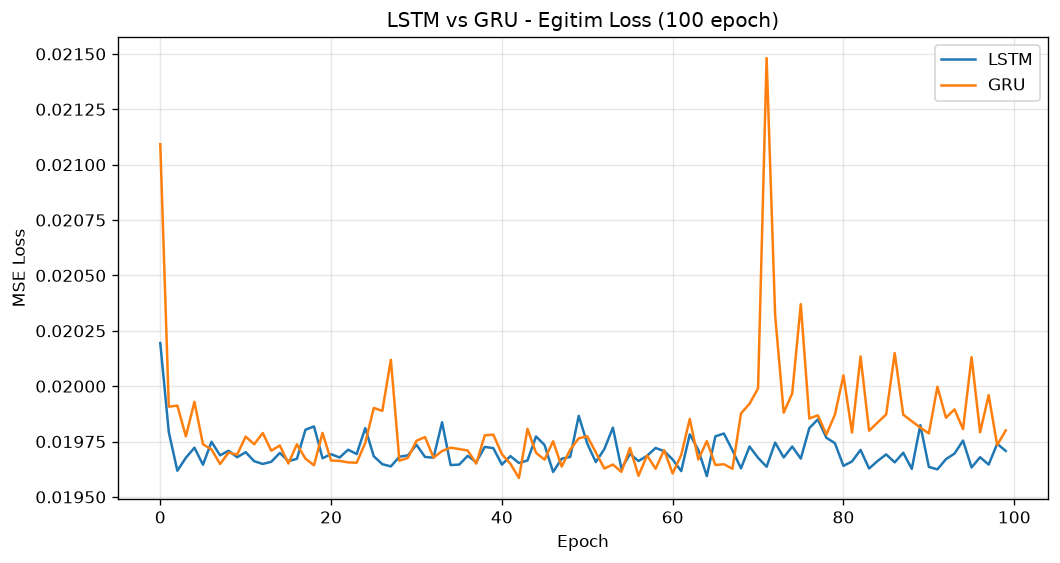

In [7]:
from models import StockGRU

torch.manual_seed(42)
gru_model = StockGRU()
gru_model, gru_losses, gru_time = train_model(gru_model, Xtr, ytr, epochs=100)

torch.save(gru_model.state_dict(), RESULTS_DIR / "gru_model.pt")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gru_losses, color="tab:orange")
ax.set_title(f"GRU Egitim Loss ({gru_time:.1f}s)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True, alpha=0.3)
show_fig(fig)

with open(RESULTS_DIR / "training_times.json", "w", encoding="utf-8") as f:
    json.dump({"lstm": lstm_time, "gru": gru_time}, f, indent=2)
with open(RESULTS_DIR / "loss_history.json", "w", encoding="utf-8") as f:
    json.dump({"lstm": lstm_losses, "gru": gru_losses}, f, indent=2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lstm_losses, label="LSTM", color="tab:blue")
ax.plot(gru_losses, label="GRU", color="tab:orange")
ax.set_title("LSTM vs GRU - Egitim Loss (100 epoch)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(RESULTS_DIR / "loss_curves.png", dpi=120)
show_fig(fig)

## 7. Değerlendirme

`evaluate.evaluate()`: Naive, Linear Regression, LSTM, GRU'yu **aynı 814 günlük test gün
kümesinde** karşılaştırır (assert ile doğrulanır). LSTM/GRU'nun tahmin ettiği ölçekli
return, `price_pred[t] = price_true[t-1] * exp(return_pred[t])` formülüyle dolara geri
çevrilir. Sonuç tablosu `results/comparison.md`'ye, grafikler `results/predictions.png` ve
`results/predictions_zoom.png`'a kaydedilir.

In [8]:
from evaluate import evaluate

rows = evaluate()

[data_loader] 'AMZN.csv' diskten okundu (indirme atlandi).
[data_loader] Satir sayisi: 4170
[data_loader] Tarih araligi: 2010-01-04 -> 2026-08-03
[explore] --- Temel istatistikler ---
             Close         High          Low         Open        Volume
count  4170.000000  4170.000000  4170.000000  4170.000000  4.170000e+03
mean     86.016713    87.022581    84.962730    86.033920  7.973950e+07
std      73.807138    74.683606    72.915505    73.834408  5.079585e+07
min       5.430500     5.564500     5.290000     5.296500  1.142050e+07
25%      15.714375    15.890000    15.564000    15.722750  4.908678e+07
50%      75.864750    77.077999    74.909000    76.275497  6.663500e+07
75%     152.856503   154.887497   150.746750   153.097256  9.489850e+07
max     284.019989   287.160004   278.000000   278.290009  8.484220e+08
[explore] Toplam NaN sayisi (fill oncesi): 0
[explore] NaN yok, fill uygulanmadi.
[explore] Is gunu takviminde eksik gun sayisi (tatiller dahil): 156
[explore] (Bu gunl

[explore] Fiyat grafigi kaydedildi: price_history.png
[preprocessing] Toplam: 4170 | Train: 3336 | Test: 834
[preprocessing] Train tarih: 2010-01-04 -> 2023-04-04
[preprocessing] Test  tarih: 2023-04-05 -> 2026-08-03
[windowing] test X shape: (814, 20, 1) | y shape: (814, 1)
[evaluate] Dogrulama OK: 4 model de ayni 814 gunluk test kumesinde degerlendirildi (test[20:], 2023-05-04 -> 2026-08-03).

Model                |   RMSE ($) |    MAE ($) |  Egitim suresi (s)
-------------------------------------------------------------------
Naive                |     4.0400 |     2.8155 |                  -
Linear Regression    |     4.0862 |     2.8661 |                  -
LSTM                 |     4.0456 |     2.8229 |              21.81
GRU                  |     4.0745 |     2.8485 |              54.52

[evaluate] comparison.md kaydedildi.


[evaluate] predictions.png kaydedildi.


[evaluate] predictions_zoom.png kaydedildi.


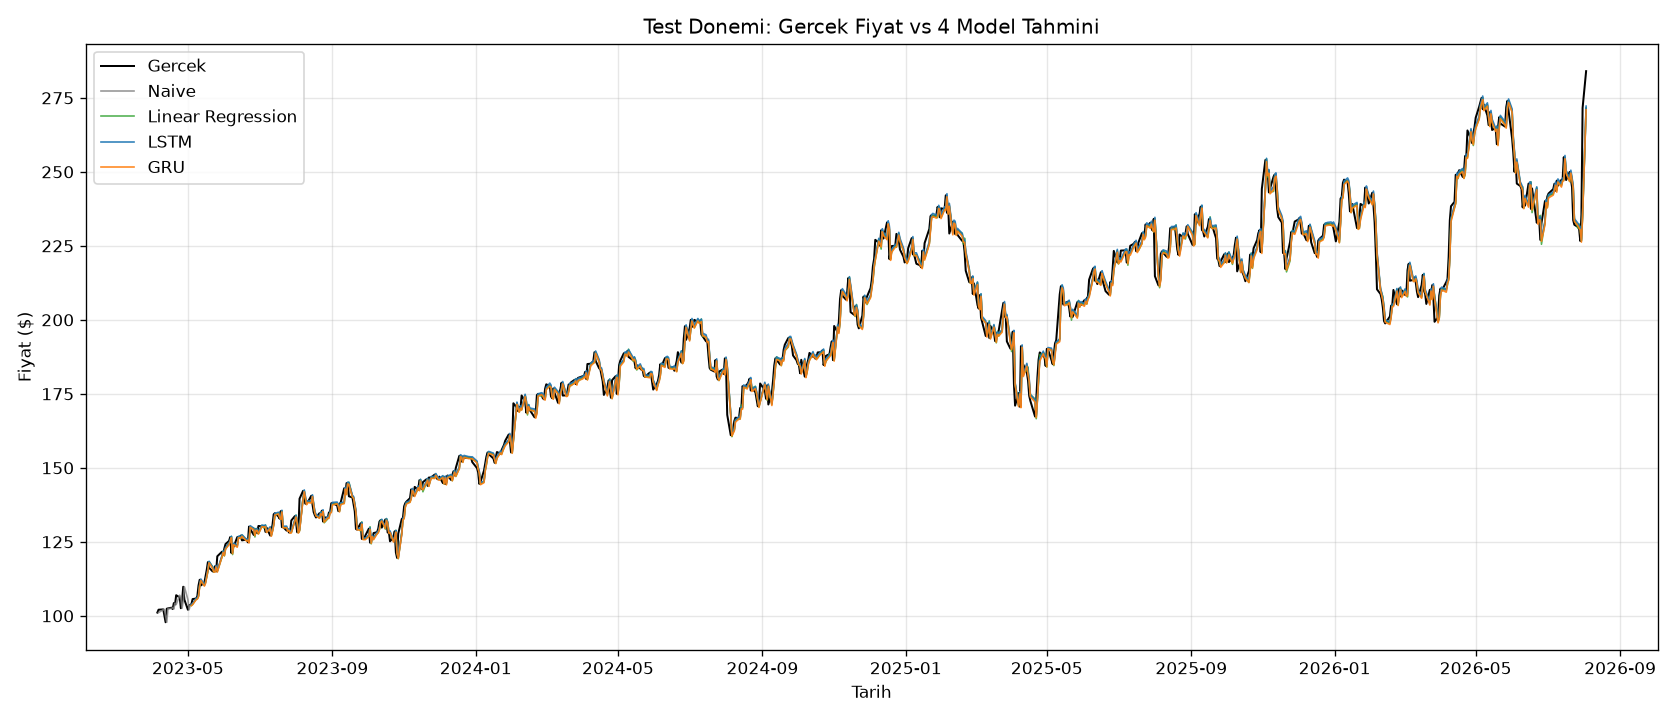

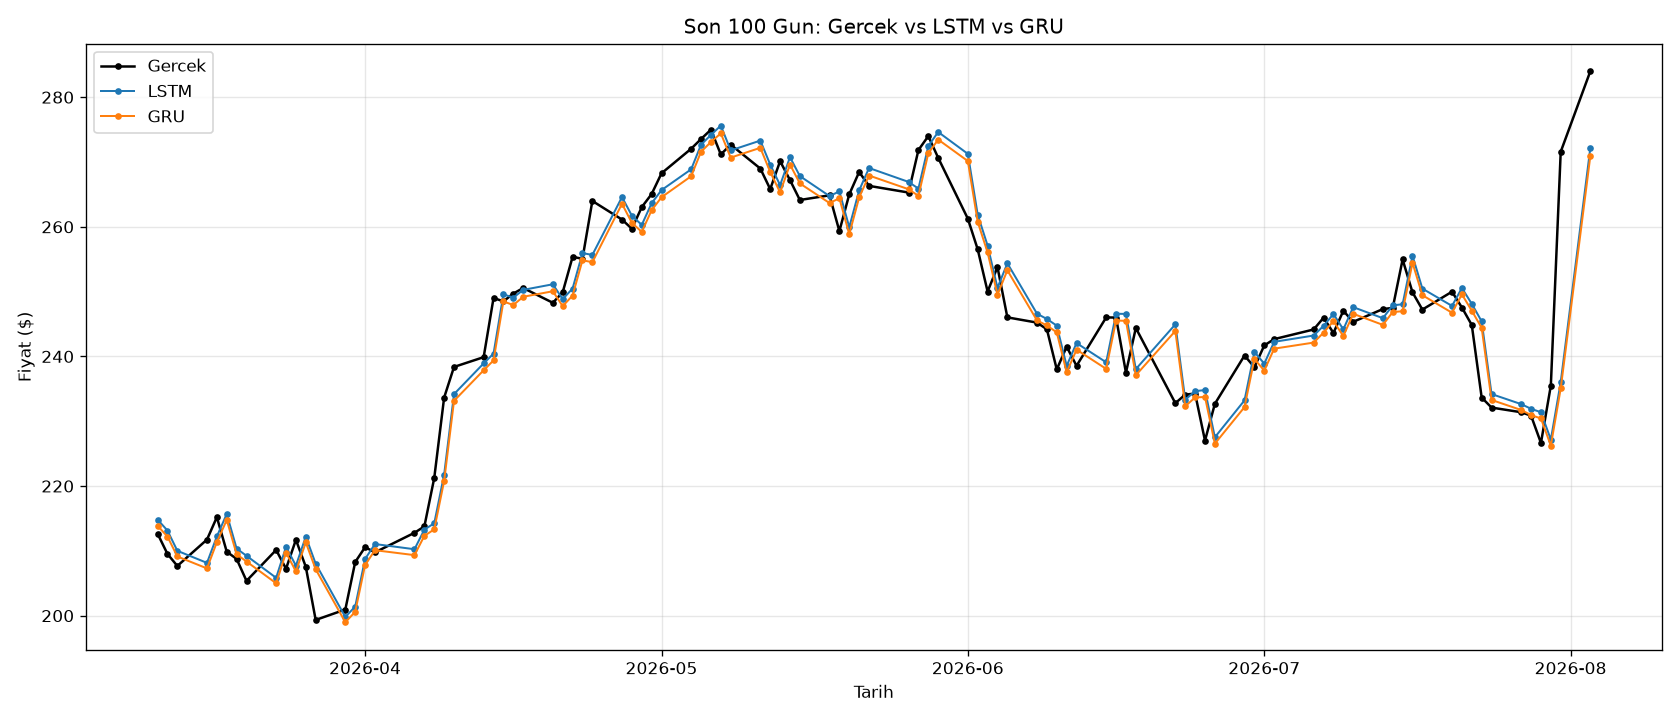

In [9]:
display(Image(filename=str(RESULTS_DIR / "predictions.png")))
display(Image(filename=str(RESULTS_DIR / "predictions_zoom.png")))

In [10]:
comparison_df = pd.DataFrame(
    [(name, m["rmse"], m["mae"], t) for name, m, t in rows],
    columns=["Model", "RMSE ($)", "MAE ($)", "Egitim suresi (s)"],
)
comparison_df

,Model,RMSE ($),MAE ($),Egitim suresi (s)
0,Naive,4.039999,2.815491,NaN
1,Linear Regression,4.086211,2.866064,NaN
2,LSTM,4.045618,2.822899,21.811469
3,GRU,4.074456,2.848533,54.517448


## Sonuçlar ve Yorum